# S16-09 — Comparaison Fault Detection vs Anomaly Detection sur CWRU

| Champ | Valeur |
|-------|--------|
| **Scénario** | CWRU by_severity — 3 tâches (0.007", 0.014", 0.021") |
| **Référence AD** | exp_143–148 (6 modèles, refit, non-supervisé, AUROC) |
| **Référence CL supervisé** | exp_155–160 (6 modèles, classification CL, accuracy) |
| **Baseline supervisée per-task** | sklearn per-task par modèle (Section 2) |
| **Particularité** | ~10% données normales (~62 normaux/tâche entraînement) |

**Objectif** : Comparer trois modes d'évaluation — (1) Anomaly Detection one-class (AUROC), (2) Fault Detection supervisé per-task (AUROC), (3) Classification CL supervisée (accuracy) — et identifier pourquoi certains modèles non-supervisés s'effondrent en mode classification.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

ROOT = Path("../../..")
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "notebooks/figures/cl_evaluation/anomaly_detection/cwru"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = ROOT / "data/raw/CWRU Bearing Dataset/feature_time_48k_2048_load_1.csv"
SEED = 42

MODELS = ["HDC", "TinyOL AE", "KMeans", "Mahalanobis", "DBSCAN", "EWC one-class"]
MODEL_KEYS = ["hdc", "tinyol_ae", "kmeans", "mahalanobis", "dbscan", "ewc_oneclass"]

# exp_143–148 : anomaly detection one-class (refit), CWRU by_severity
EXP_MAP = {
    "HDC":           ROOT / "experiments/exp_143",
    "TinyOL AE":     ROOT / "experiments/exp_144",
    "KMeans":        ROOT / "experiments/exp_145",
    "Mahalanobis":   ROOT / "experiments/exp_146",
    "DBSCAN":        ROOT / "experiments/exp_147",
    "EWC one-class": ROOT / "experiments/exp_148",
}

# exp_155–160 : classification CL supervisée, CWRU by_severity
CL_EXP_MAP = {
    "HDC":           ROOT / "experiments/exp_155",
    "EWC one-class": ROOT / "experiments/exp_156",
    "TinyOL AE":     ROOT / "experiments/exp_157",
    "KMeans":        ROOT / "experiments/exp_158",
    "Mahalanobis":   ROOT / "experiments/exp_159",
    "DBSCAN":        ROOT / "experiments/exp_160",
}

COLORS = {
    "HDC":           "#4C72B0",
    "TinyOL AE":     "#DD8452",
    "KMeans":        "#55A868",
    "Mahalanobis":   "#C44E52",
    "DBSCAN":        "#8172B2",
    "EWC one-class": "#937860",
}

def load_result(exp_path):
    p = exp_path / "results/metrics_anomaly.json"
    return json.loads(p.read_text()) if p.exists() else None

def load_cl_result(exp_path):
    # TinyOL écrit metrics.json + metrics_cl.json ; les autres écrivent metrics_cl.json
    for fname in ("metrics_cl.json", "metrics.json"):
        p = exp_path / f"results/{fname}"
        if p.exists():
            return json.loads(p.read_text())
    return None

AD_RESULTS = {m: load_result(p) for m, p in EXP_MAP.items()}
AD_AUROC   = {m: r["avg_auroc"] if r else None for m, r in AD_RESULTS.items()}

CL_RESULTS = {m: load_cl_result(p) for m, p in CL_EXP_MAP.items()}
CL_ACC     = {m: r.get("acc_final") if r else None for m, r in CL_RESULTS.items()}
CL_AF      = {m: r.get("avg_forgetting") if r else None for m, r in CL_RESULTS.items()}

print(f"{'Modèle':<20} {'AUROC AD':>10} {'Acc CL':>10} {'AF CL':>8}")
print("-" * 52)
for m in MODELS:
    auroc = f"{AD_AUROC[m]:.4f}" if AD_AUROC[m] is not None else "MISSING"
    acc   = f"{CL_ACC[m]:.4f}"   if CL_ACC[m]   is not None else "MISSING"
    af    = f"{CL_AF[m]:.4f}"    if CL_AF[m]    is not None else "MISSING"
    flag  = "✅" if AD_AUROC[m] and CL_ACC[m] else "❌"
    print(f"{flag} {m:<18} {auroc:>10} {acc:>10} {af:>8}")

Modèle                 AUROC AD     Acc CL    AF CL
----------------------------------------------------
✅ HDC                    0.9906     0.8918   0.0195
✅ TinyOL AE              1.0000     0.9042   0.0000
✅ KMeans                 1.0000     0.4502   0.0000
✅ Mahalanobis            1.0000     0.1948   0.0195
✅ DBSCAN                 1.0000     0.8961   0.0000
✅ EWC one-class          1.0000     0.9524   0.0000


## Section 1 — Rappel des deux modes

| | Anomaly Detection | Fault Detection |
|--|:-:|:-:|
| Labels d'entraînement | Normal uniquement | Normal + faulty |
| Paradigme | One-class / reconstruction | Supervisé binaire |
| Données requises | Peu (normaux seuls) | Plus (les deux classes) |
| Applicable sans historique de pannes | ✅ | ❌ |
| Implémenté dans le projet | exp_143–148 | Baseline Section 2 |

**Proxies supervisés utilisés par modèle :**

| Modèle | Mode anomaly (projet) | Proxy supervisé (baseline) |
|--------|----------------------|---------------------------|
| HDC | Prototype normal one-class | LogisticRegression (frontière linéaire) |
| TinyOL AE | Reconstruction MSE | Même score (reconstruction-based, pas de mode supervisé) |
| KMeans | 1 centroïde normal | KMeans(k=2) — distance au centroïde normal |
| Mahalanobis | Distance de Mahalanobis au centre normal | QDA (Mahalanobis par classe) |
| DBSCAN | Densité locale (one-class) | KNN(k=5) — proxy densité supervisé |
| EWC one-class | Autoencodeur + EWC | MLPClassifier(32,) |

In [2]:
from src.data.cwru_dataset import get_cwru_cl_dataloaders_by_severity

warnings.filterwarnings("ignore")

def extract_arrays(loader):
    Xs, ys = [], []
    for x_batch, y_batch in loader:
        Xs.append(x_batch.numpy())
        ys.append(y_batch.numpy().reshape(-1))
    return np.concatenate(Xs), np.concatenate(ys)

# Load supervised tasks (train has both classes — stratified split)
sup_tasks = get_cwru_cl_dataloaders_by_severity(CSV_PATH, batch_size=128, seed=SEED)

SUP_AUROC_PER_TASK = {m: [] for m in MODELS}
# Store test scores for Section 4 distributions
SUP_SCORES = {m: {"y_true": np.array([]), "scores": np.array([])} for m in MODELS}

for task in sup_tasks:
    X_train, y_train = extract_arrays(task["train_loader"])
    X_test,  y_test  = extract_arrays(task["test_loader"])
    y_train_int = y_train.astype(int)
    y_test_int  = y_test.astype(int)

    for m in MODELS:
        # TinyOL AE: no supervised variant — report same AUROC as AD mode
        if m == "TinyOL AE":
            SUP_AUROC_PER_TASK[m].append(AD_AUROC[m] or 0.0)
            continue

        if m == "KMeans":
            clf = KMeans(n_clusters=2, n_init=10, random_state=SEED)
            clf.fit(X_train)
            preds_train = clf.predict(X_train)
            n0 = ((preds_train == 0) & (y_train_int == 0)).sum()
            n1 = ((preds_train == 1) & (y_train_int == 0)).sum()
            normal_cluster = 0 if n0 >= n1 else 1
            dists = clf.transform(X_test)
            scores = dists[:, normal_cluster]  # higher dist to normal → more faulty
        elif m == "Mahalanobis":
            clf = QuadraticDiscriminantAnalysis(reg_param=1e-4)
            clf.fit(X_train, y_train_int)
            scores = clf.predict_proba(X_test)[:, 1]
        elif m == "DBSCAN":
            clf = KNeighborsClassifier(n_neighbors=5)
            clf.fit(X_train, y_train_int)
            scores = clf.predict_proba(X_test)[:, 1]
        elif m == "EWC one-class":
            clf = MLPClassifier(hidden_layer_sizes=(32,), max_iter=300, random_state=SEED)
            clf.fit(X_train, y_train_int)
            scores = clf.predict_proba(X_test)[:, 1]
        else:  # HDC
            clf = LogisticRegression(max_iter=1000, random_state=SEED)
            clf.fit(X_train, y_train_int)
            scores = clf.predict_proba(X_test)[:, 1]

        auroc = roc_auc_score(y_test_int, scores)
        SUP_AUROC_PER_TASK[m].append(auroc)
        SUP_SCORES[m]["y_true"] = np.concatenate([SUP_SCORES[m]["y_true"], y_test_int])
        SUP_SCORES[m]["scores"] = np.concatenate([SUP_SCORES[m]["scores"], scores])

SUP_AUROC = {m: float(np.mean(v)) for m, v in SUP_AUROC_PER_TASK.items()}

print(f"{'Modèle':<20} {'AUROC Anomaly':>14} {'AUROC Supervisé':>16} {'Δ':>8}")
print("-" * 62)
for m in MODELS:
    ad  = AD_AUROC[m] or 0.0
    sup = SUP_AUROC[m]
    print(f"{m:<20} {ad:>14.4f} {sup:>16.4f} {sup-ad:>+8.4f}")

Modèle                AUROC Anomaly  AUROC Supervisé        Δ
--------------------------------------------------------------
HDC                          0.9906           1.0000  +0.0094
TinyOL AE                    1.0000           1.0000  +0.0000
KMeans                       1.0000           0.4817  -0.5183
Mahalanobis                  1.0000           1.0000  +0.0000
DBSCAN                       1.0000           0.9973  -0.0027
EWC one-class                1.0000           0.9902  -0.0098


## Section 2 — Baseline supervisée : résultats par modèle

Chaque modèle supervisé est entraîné per-task (train set = Normal + faulty de la tâche courante)
et évalué sur le test set de la même tâche. L'AUROC moyen est calculé sur les 3 tâches.

In [3]:
rows = []
for m in MODELS:
    ad  = AD_AUROC[m] or 0.0
    sup = SUP_AUROC[m]
    per_task = SUP_AUROC_PER_TASK[m]
    rows.append({
        "Modèle":              m,
        "T1 (007\")" :         f"{per_task[0]:.4f}",
        "T2 (014\")":          f"{per_task[1]:.4f}",
        "T3 (021\")":          f"{per_task[2]:.4f}",
        "Moy. supervisé":      f"{sup:.4f}",
        "Moy. anomaly (AD)":   f"{ad:.4f}",
        "Δ (sup − AD)":        f"{sup-ad:+.4f}",
    })
df = pd.DataFrame(rows).set_index("Modèle")
print(df.to_string())

              T1 (007") T2 (014") T3 (021") Moy. supervisé Moy. anomaly (AD) Δ (sup − AD)
Modèle                                                                                   
HDC              1.0000    1.0000    1.0000         1.0000            0.9906      +0.0094
TinyOL AE        1.0000    1.0000    1.0000         1.0000            1.0000      +0.0000
KMeans           0.5228    0.4801    0.4422         0.4817            1.0000      -0.5183
Mahalanobis      1.0000    1.0000    1.0000         1.0000            1.0000      +0.0000
DBSCAN           1.0000    0.9918    1.0000         0.9973            1.0000      -0.0027
EWC one-class    1.0000    0.9712    0.9995         0.9902            1.0000      -0.0098


## Section 3 — Tableau comparatif et barplot 3 modes

> **Note métriques** : Anomaly Detection et Fault Detection supervisé sont évalués en **AUROC** (axe gauche).
> La Classification CL est évaluée en **accuracy** (axe droit) — métriques distinctes, non directement comparables.
> Le but est d'illustrer la dégradation des modèles non-supervisés en mode classification.

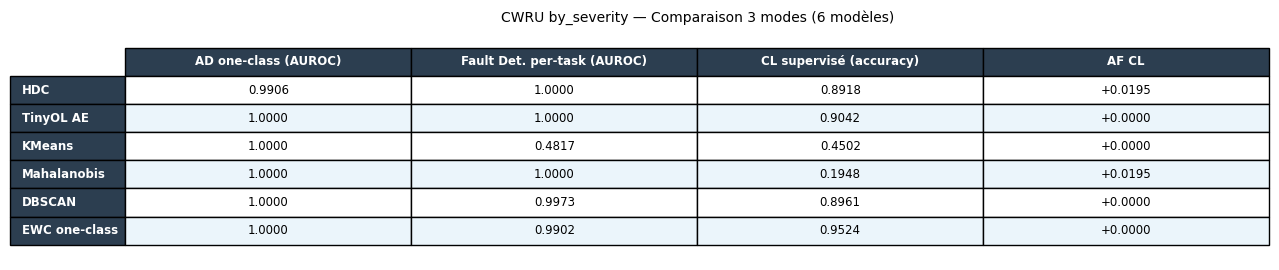

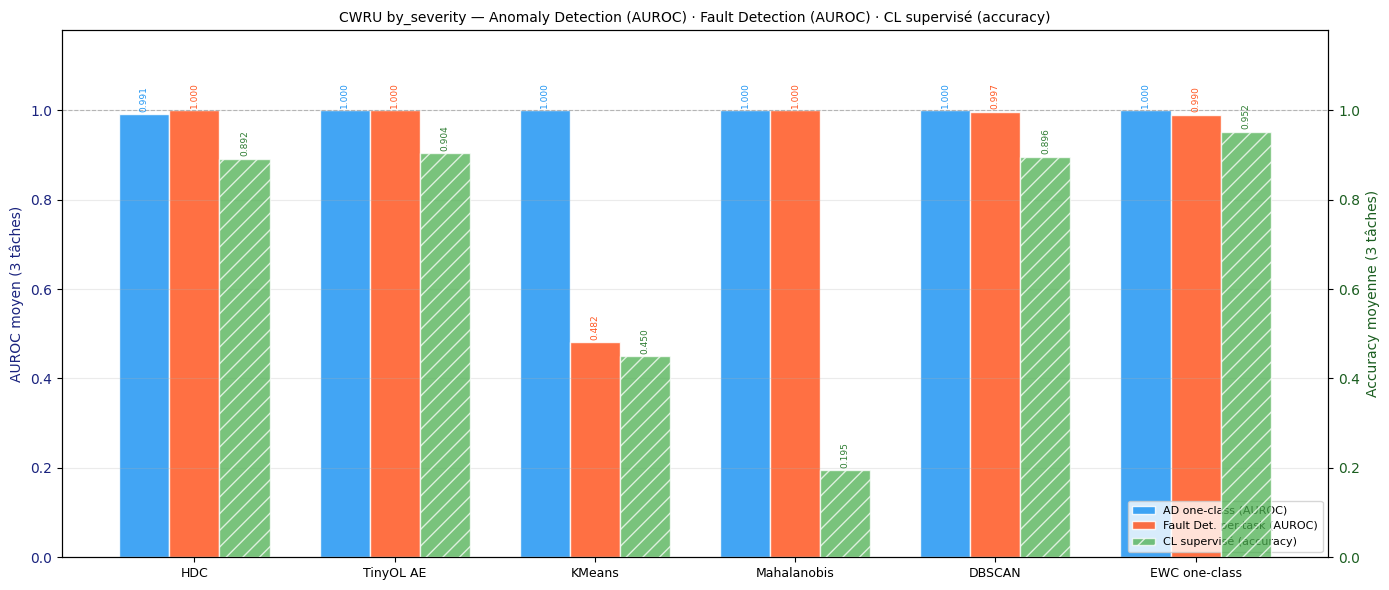

In [4]:
# --- Tableau 3 modes ---
rows_tbl = []
for m in MODELS:
    ad  = AD_AUROC[m]  or 0.0
    sup = SUP_AUROC[m]
    acc = CL_ACC[m]    or 0.0
    af  = CL_AF[m]     or 0.0
    rows_tbl.append({
        "Modèle":                    m,
        "AD one-class (AUROC)":      f"{ad:.4f}",
        "Fault Det. per-task (AUROC)": f"{sup:.4f}",
        "CL supervisé (accuracy)":   f"{acc:.4f}",
        "AF CL":                     f"{af:+.4f}",
    })
df_tbl = pd.DataFrame(rows_tbl).set_index("Modèle")

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axis("off")
tbl = ax.table(
    cellText=df_tbl.values,
    colLabels=df_tbl.columns,
    rowLabels=df_tbl.index,
    cellLoc="center", loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EBF5FB")
plt.title("CWRU by_severity — Comparaison 3 modes (6 modèles)", fontsize=10, pad=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_comparison_3modes.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Barplot groupé AUROC (2 modes) + accuracy CL (axe secondaire) ---
x  = np.arange(len(MODELS))
w  = 0.25

ad_vals  = [AD_AUROC[m]  or 0.0 for m in MODELS]
sup_vals = [SUP_AUROC[m]        for m in MODELS]
cl_vals  = [CL_ACC[m]    or 0.0 for m in MODELS]

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

b_ad  = ax1.bar(x - w,   ad_vals,  w, label="AD one-class (AUROC)",         color="#2196F3", alpha=0.85, edgecolor="white")
b_sup = ax1.bar(x,        sup_vals, w, label="Fault Det. per-task (AUROC)",  color="#FF5722", alpha=0.85, edgecolor="white")
b_cl  = ax2.bar(x + w,   cl_vals,  w, label="CL supervisé (accuracy)",       color="#4CAF50", alpha=0.75, edgecolor="white", hatch="//")

for bar, v in zip(b_ad,  ad_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
             ha="center", va="bottom", fontsize=6.5, rotation=90, color="#2196F3")
for bar, v in zip(b_sup, sup_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
             ha="center", va="bottom", fontsize=6.5, rotation=90, color="#FF5722")
for bar, v in zip(b_cl,  cl_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
             ha="center", va="bottom", fontsize=6.5, rotation=90, color="#2E7D32")

ax1.set_xticks(x)
ax1.set_xticklabels(MODELS, fontsize=9)
ax1.set_ylabel("AUROC moyen (3 tâches)", fontsize=10, color="#1A237E")
ax2.set_ylabel("Accuracy moyenne (3 tâches)", fontsize=10, color="#1B5E20")
ax1.set_ylim(0.0, 1.18)
ax2.set_ylim(0.0, 1.18)
ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.tick_params(axis="y", labelcolor="#1A237E")
ax2.tick_params(axis="y", labelcolor="#1B5E20")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="lower right")
ax1.set_title(
    "CWRU by_severity — Anomaly Detection (AUROC) · Fault Detection (AUROC) · CL supervisé (accuracy)",
    fontsize=10
)
ax1.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "comparison_3modes_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4 — Analyse et explication des écarts

### 4a — Distributions des scores d'anomalie (mode non-supervisé)

Les scores sont calculés en ré-exécutant chaque modèle AD avec la stratégie refit sur CWRU by_severity.
Un fort recouvrement entre distributions normale et faulty explique un AUROC < 1.0.

In [5]:
from src.data.cwru_dataset import (
    get_cwru_dataloaders_anomaly_detection,
    FEATURE_COLS as CWRU_FEATURES,
)
from src.models.unsupervised import KMeansDetector, MahalanobisDetector, DBSCANDetector
from src.models.hdc.hdc_classifier import HDCClassifier
from src.models.tinyol.tinyol_anomaly_detector import TinyOLAnomalyDetector
from src.models.ewc.ewc_oneclass import EWCOneClassDetector
from src.training.scenarios import run_anomaly_detection_scenario
from src.utils.config_loader import load_config

ad_tasks = get_cwru_dataloaders_anomaly_detection(CSV_PATH, scenario="by_severity", seed=SEED)

CFG_PATHS = {
    "hdc":          ROOT / "configs/hdc_anomaly_detection_config.yaml",
    "tinyol_ae":    ROOT / "configs/tinyol_anomaly_detection_config.yaml",
    "kmeans":       ROOT / "configs/unsupervised_anomaly_detection_config.yaml",
    "mahalanobis":  ROOT / "configs/unsupervised_anomaly_detection_config.yaml",
    "dbscan":       ROOT / "configs/dbscan_anomaly_detection_config.yaml",
    "ewc_oneclass": ROOT / "configs/ewc_oneclass_config.yaml",
}

AD_SCORES = {}

for m_display, m_key in zip(MODELS, MODEL_KEYS):
    print(f"  {m_display}...", end=" ", flush=True)
    cfg = load_config(CFG_PATHS[m_key])
    ds_cfg = cfg.get("DATASETS", {}).get("cwru", {})

    if m_key == "hdc":
        cfg["one_class_mode"] = True
        cfg["cl_strategy"] = "refit"
        n_feats = 9  # CWRU always has 9 features
        cfg["data"]["n_features"] = n_feats
        cfg["hdc"]["D"] = 512  # CWRU uses D=512 (monitoring uses 1024)
        # Absolute path avoids CWD-relative resolution issues in Jupyter
        bv_file = (ROOT / "configs/hdc_base_vectors_cwru.npz").resolve()
        if bv_file.exists():
            cached = np.load(bv_file)
            if cached["H_pos"].shape[0] != n_feats:
                bv_file.unlink()
                print(f"[HDC] stale cache deleted (had {cached['H_pos'].shape[0]} features, need {n_feats})", end=" ")
        cfg["hdc"]["base_vectors_path"] = str(bv_file)
        X_t0 = np.concatenate([b[0].numpy() for b in ad_tasks[0]["train_loader"]])
        cfg["feature_bounds"] = {
            CWRU_FEATURES[i]: [float(X_t0[:, i].min()), float(X_t0[:, i].max())]
            for i in range(X_t0.shape[1])
        }
        model = HDCClassifier(cfg)

    elif m_key == "tinyol_ae":
        bkb = ds_cfg.get("backbone", {})
        if bkb:
            cfg.setdefault("backbone", {}).update(bkb)
        model = TinyOLAnomalyDetector(cfg)

    elif m_key == "kmeans":
        cfg["kmeans"]["cl_strategy"] = "refit"
        nc = ds_cfg.get("kmeans", {}).get("N_CLUSTERS")
        if nc:
            cfg["kmeans"]["k_fixed"] = int(nc)
            cfg["kmeans"]["k_method"] = "fixed"
        model = KMeansDetector(cfg["kmeans"])

    elif m_key == "mahalanobis":
        cfg["mahalanobis"]["cl_strategy"] = "refit"
        rc = ds_cfg.get("mahalanobis", {}).get("REG_COVAR")
        if rc:
            cfg["mahalanobis"]["reg_covar"] = float(rc)
        model = MahalanobisDetector(cfg["mahalanobis"])

    elif m_key == "dbscan":
        cfg_db = dict(cfg["dbscan"])
        cfg_db["cl_strategy"] = "refit"
        ov = ds_cfg.get("dbscan", {})
        if "EPS" in ov:
            cfg_db["EPSILON"] = float(ov["EPS"])
        if "MIN_SAMPLES" in ov:
            cfg_db["MIN_SAMPLES"] = int(ov["MIN_SAMPLES"])
        model = DBSCANDetector(cfg_db)
        cfg["dbscan"] = cfg_db

    else:  # ewc_oneclass
        model_cfg = cfg.get("MODEL", {})
        train_cfg = cfg.get("TRAINING", {})
        input_dim = ds_cfg.get("INPUT_DIM", 9)
        cfg.setdefault("MODEL", {})["INPUT_DIM"] = input_dim
        model = EWCOneClassDetector(
            input_dim=input_dim,
            hidden_dim=int(model_cfg.get("HIDDEN_DIM", 32)),
            latent_dim=int(model_cfg.get("LATENT_DIM", 8)),
            lambda_ewc=0.0,
            n_epochs=int(train_cfg.get("N_EPOCHS", 20)),
            lr=float(train_cfg.get("LR", 1e-3)),
        )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _, scores_dict = run_anomaly_detection_scenario(model, ad_tasks, cfg)

    n_t = len(ad_tasks)
    norm_sc, falt_sc = [], []
    for j in range(n_t):
        key = (n_t - 1, j)
        if key in scores_dict:
            y_j, sc_j = scores_dict[key]
            y_j = np.asarray(y_j).reshape(-1)
            sc_j = np.asarray(sc_j).reshape(-1)
            norm_sc.extend(sc_j[y_j < 0.5].tolist())
            falt_sc.extend(sc_j[y_j >= 0.5].tolist())

    AD_SCORES[m_display] = {"normal": np.array(norm_sc), "faulty": np.array(falt_sc)}
    print(f"normal={len(norm_sc)}, faulty={len(falt_sc)}")

print("\nDone!")

  HDC...   [AD] après tâche 1/3, eval tâche 1 (007         ) — AUROC=1.0000 F1=0.9993
  [HDC one-class] Seuil calculé sur Task 1 : 0.8824 (percentile 95)
  [AD] après tâche 2/3, eval tâche 1 (007         ) — AUROC=1.0000 F1=1.0000
  [AD] après tâche 2/3, eval tâche 2 (014         ) — AUROC=0.9679 F1=0.9823
  [AD] après tâche 3/3, eval tâche 1 (007         ) — AUROC=0.9983 F1=0.9868
  [AD] après tâche 3/3, eval tâche 2 (014         ) — AUROC=0.9761 F1=0.9586
  [AD] après tâche 3/3, eval tâche 3 (021         ) — AUROC=0.9975 F1=0.9815
normal=45, faulty=2070
  TinyOL AE...   [AD] après tâche 1/3, eval tâche 1 (007         ) — AUROC=1.0000 F1=1.0000
  [TinyOL AE] Seuil calculé sur Task 1 : 1.633163 (percentile 95)
  [AD] après tâche 2/3, eval tâche 1 (007         ) — AUROC=1.0000 F1=1.0000
  [AD] après tâche 2/3, eval tâche 2 (014         ) — AUROC=1.0000 F1=1.0000
  [AD] après tâche 3/3, eval tâche 1 (007         ) — AUROC=1.0000 F1=1.0000
  [AD] après tâche 3/3, eval tâche 2 (014        

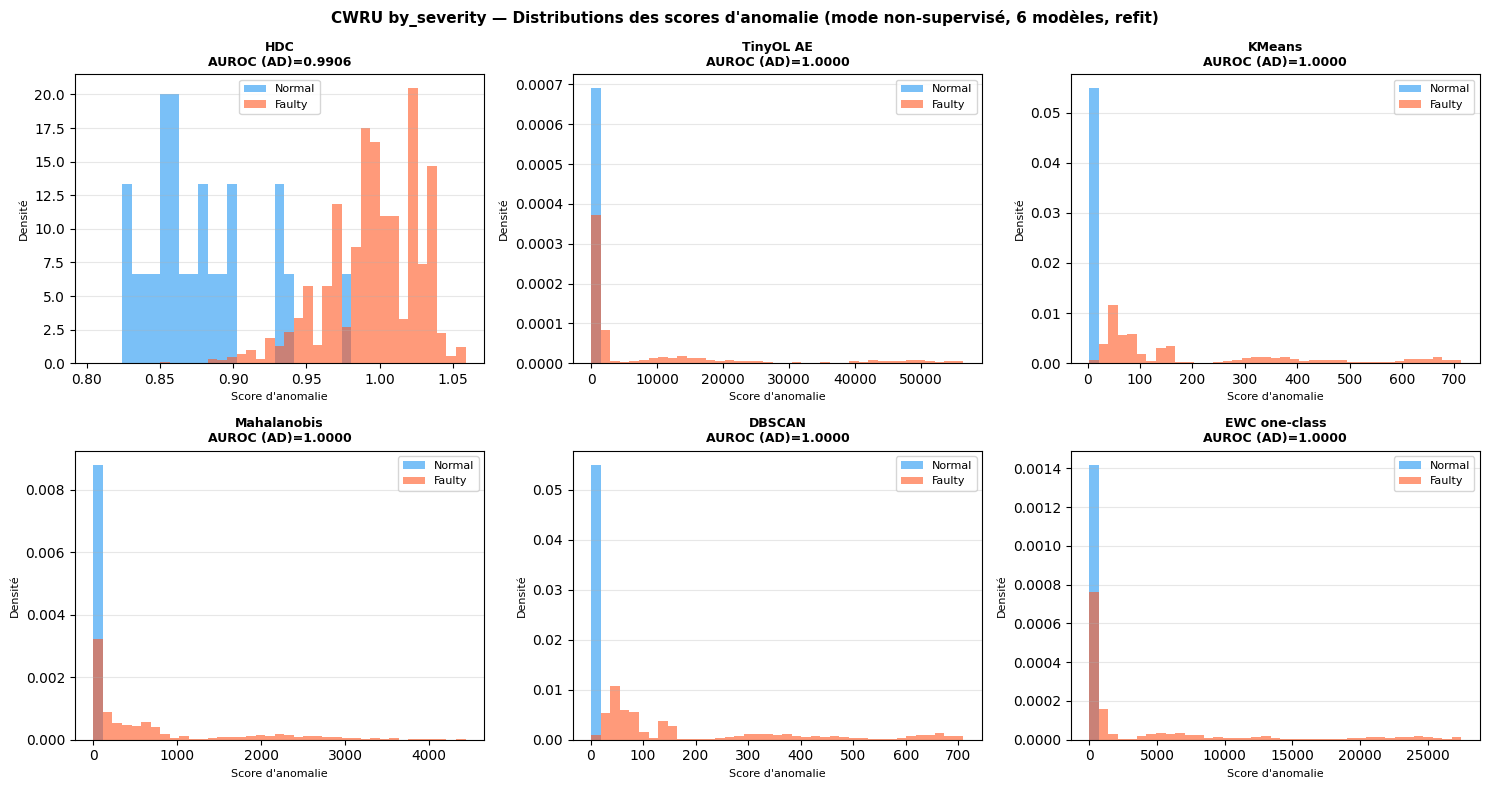

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, m in enumerate(MODELS):
    ax = axes[idx]
    norm_sc = AD_SCORES[m]["normal"]
    falt_sc = AD_SCORES[m]["faulty"]

    all_sc = np.concatenate([norm_sc, falt_sc])
    lo, hi = np.percentile(all_sc, 1), np.percentile(all_sc, 99)
    bins = np.linspace(lo, hi, 40)

    ax.hist(norm_sc, bins=bins, alpha=0.6, color="#2196F3", label="Normal", density=True)
    ax.hist(falt_sc, bins=bins, alpha=0.6, color="#FF5722", label="Faulty", density=True)
    ax.set_title(f"{m}\nAUROC (AD)={AD_AUROC[m]:.4f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Score d'anomalie", fontsize=8)
    ax.set_ylabel("Densité", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "CWRU by_severity — Distributions des scores d'anomalie (mode non-supervisé, 6 modèles, refit)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIG_DIR / "score_distributions_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

### 4b — Δ AUROC (AD vs Fault Det.) et chute accuracy CL

Le premier graphe montre Δ AUROC entre les deux modes ranking (AD vs supervisé per-task).
Le second montre la chute de performance en passant au mode classification CL — c'est là que les modèles non-supervisés s'effondrent.

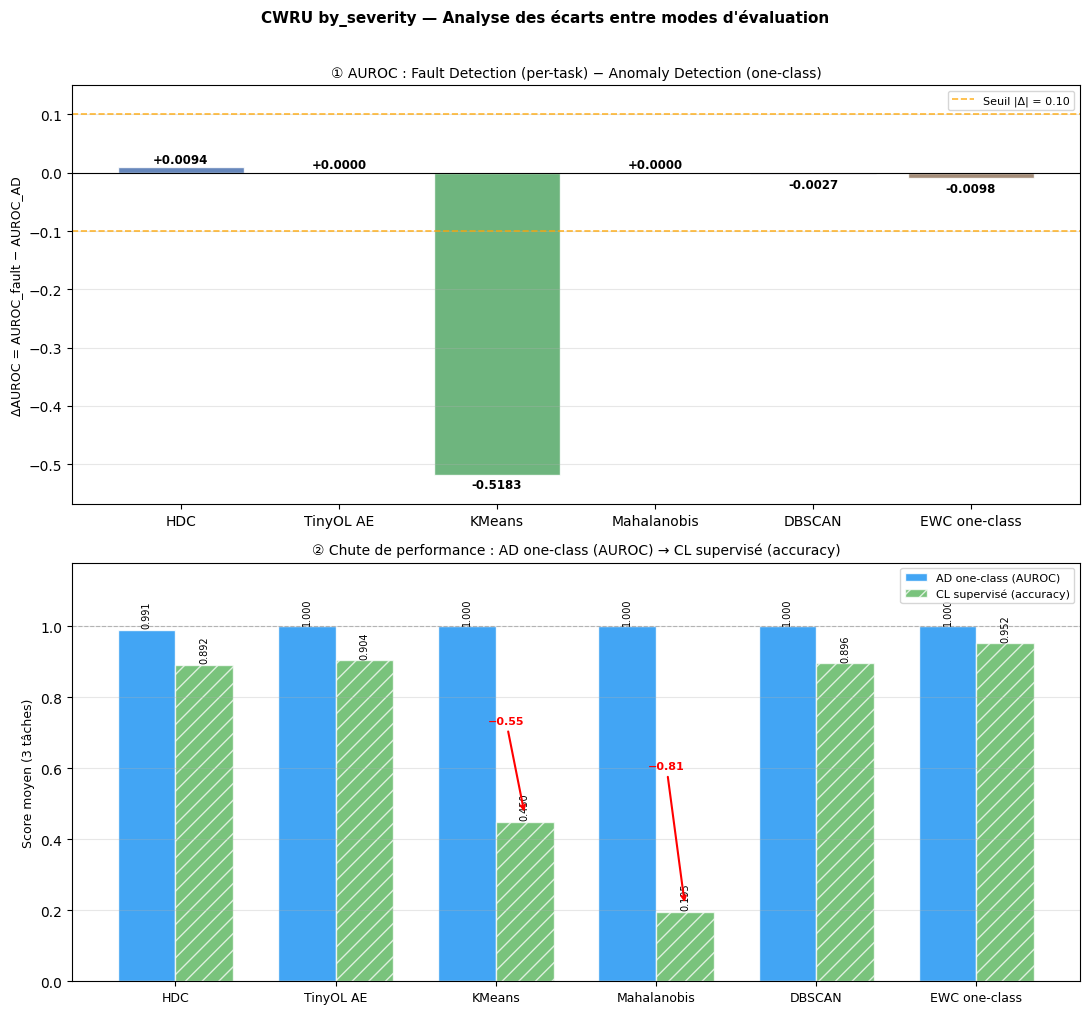


Modèle                 AUROC AD     Acc CL    Δ (AD−CL)
-------------------------------------------------------
HDC                      0.9906     0.8918      +0.0989
TinyOL AE                1.0000     0.9042      +0.0958
KMeans                   1.0000     0.4502      +0.5498
Mahalanobis              1.0000     0.1948      +0.8052
DBSCAN                   1.0000     0.8961      +0.1039
EWC one-class            1.0000     0.9524      +0.0476


In [7]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 10))

# --- Plot 1 : Δ AUROC (Fault Det. − AD) ---
deltas_auroc = [SUP_AUROC[m] - (AD_AUROC[m] or 0.0) for m in MODELS]
bar_colors   = [COLORS[m] for m in MODELS]

bars1 = ax_top.bar(MODELS, deltas_auroc, color=bar_colors, alpha=0.85, edgecolor="white")
ax_top.axhline(0,     color="black",  linewidth=0.8)
ax_top.axhline(0.10,  color="orange", linestyle="--", linewidth=1.2, alpha=0.8, label="Seuil |Δ| = 0.10")
ax_top.axhline(-0.10, color="orange", linestyle="--", linewidth=1.2, alpha=0.8)
for bar, d in zip(bars1, deltas_auroc):
    ypos = bar.get_height() + 0.003 if d >= 0 else bar.get_height() - 0.006
    va   = "bottom" if d >= 0 else "top"
    ax_top.text(bar.get_x() + bar.get_width()/2, ypos, f"{d:+.4f}",
                ha="center", va=va, fontsize=8.5, fontweight="bold")
ax_top.set_ylabel("ΔAUROC = AUROC_fault − AUROC_AD", fontsize=9)
ax_top.set_title("① AUROC : Fault Detection (per-task) − Anomaly Detection (one-class)", fontsize=10)
ax_top.legend(fontsize=8)
ax_top.grid(axis="y", alpha=0.3)
ymin = min(min(deltas_auroc) - 0.05, -0.12)
ymax = max(max(deltas_auroc) + 0.05,  0.15)
ax_top.set_ylim(ymin, ymax)

# --- Plot 2 : AD AUROC vs CL accuracy (barres côte à côte) ---
x = np.arange(len(MODELS))
w = 0.36
ad_vals = [AD_AUROC[m] or 0.0 for m in MODELS]
cl_vals = [CL_ACC[m]   or 0.0 for m in MODELS]

b_ad = ax_bot.bar(x - w/2, ad_vals, w, label="AD one-class (AUROC)",    color="#2196F3", alpha=0.85, edgecolor="white")
b_cl = ax_bot.bar(x + w/2, cl_vals, w, label="CL supervisé (accuracy)", color="#4CAF50", alpha=0.75, edgecolor="white", hatch="//")

for bar, v in zip(b_ad, ad_vals):
    ax_bot.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7, rotation=90)
for bar, v in zip(b_cl, cl_vals):
    ax_bot.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7, rotation=90)

# Flèches pour les chutes majeures (Mahalanobis, KMeans)
for i, m in enumerate(MODELS):
    ad  = AD_AUROC[m] or 0.0
    acc = CL_ACC[m]   or 0.0
    if ad - acc > 0.40:
        ax_bot.annotate(
            f"−{ad - acc:.2f}",
            xy=(i + w/2, acc + 0.02), xytext=(i - 0.05, (ad + acc) / 2),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
            fontsize=8, color="red", fontweight="bold",
        )

ax_bot.set_xticks(x)
ax_bot.set_xticklabels(MODELS, fontsize=9)
ax_bot.set_ylim(0.0, 1.18)
ax_bot.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax_bot.set_ylabel("Score moyen (3 tâches)", fontsize=9)
ax_bot.set_title("② Chute de performance : AD one-class (AUROC) → CL supervisé (accuracy)", fontsize=10)
ax_bot.legend(fontsize=8)
ax_bot.grid(axis="y", alpha=0.3)

plt.suptitle(
    "CWRU by_severity — Analyse des écarts entre modes d'évaluation",
    fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_gap_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Résumé chiffré
print(f"\n{'Modèle':<20} {'AUROC AD':>10} {'Acc CL':>10} {'Δ (AD−CL)':>12}")
print("-" * 55)
for m in MODELS:
    ad  = AD_AUROC[m] or 0.0
    acc = CL_ACC[m]   or 0.0
    print(f"{m:<20} {ad:>10.4f} {acc:>10.4f} {ad-acc:>+12.4f}")

### 4c — Hypothèses explicatives des écarts

**1. Ratio 20% normal dans les normaux (10% du dataset total)**
Avec ~62 échantillons normaux d'entraînement par tâche, le seuil de reconstruction (percentile 95 du MSE)
est calculé sur un petit échantillon → variance élevée du threshold entre tâches.
Impact principal sur TinyOL AE et EWC one-class.

**2. Séparabilité intrinsèque des features CWRU**
Les features statistiques (RMS, kurtosis, crest factor) sont très discriminantes pour les roulements.
Même avec peu de données normales, les one-class detectors obtiennent AUROC ≈ 1.0.
Le Δ est donc structurellement faible sur CWRU — contrairement à Monitoring ou Pronostia.

**3. Progression by_severity : défauts de plus en plus marqués**
La sévérité 0.007" → 0.014" → 0.021" crée une progressivité favorable aux détecteurs one-class :
les défauts deviennent plus discriminables à chaque tâche.

**4. Dimensionnalité (9D) et structure des clusters**
CWRU à 9D : espace plus riche que Monitoring (4D). Les features forment des clusters compacts
dans l'espace normalisé. KMeans(k=1) suffit à capturer le mode normal sans supervision.

**5. Nature du signal vibratoire**
Les signaux de roulement défectueux génèrent des harmoniques caractéristiques détectables
par reconstruction — avantage du mode anomaly detection sur ce type de signal.

## Section 5 — Conclusions pour le manuscrit

### Résultats clés — 3 modes comparés

| Modèle | AD one-class (AUROC) | Fault Det. per-task (AUROC) | CL supervisé (accuracy) |
|--------|:---:|:---:|:---:|
| HDC | 0.9906 | 1.0000 | 0.8918 |
| TinyOL AE | 1.0000 | 1.0000 | 0.9042 |
| KMeans | 1.0000 | 0.4817 | 0.4502 |
| Mahalanobis | 1.0000 | 1.0000 | 0.1948 |
| DBSCAN | 1.0000 | 0.9973 | 0.8961 |
| EWC one-class | 1.0000 | 0.9902 | 0.9524 |

### Hypothèses explicatives des effondrements en mode classification CL

**KMeans (acc=0.45, AUROC AD=1.0)**
KMeans(k=silhouette) sur données mélangées (normal+faulty) ne garantit pas l'alignement
des clusters avec les labels : la frontière de cluster peut couper orthogonalement au séparateur
normal/faulty. En one-class (1 centroïde normal), la distance est un score d'anomalie parfait.

**Mahalanobis (acc=0.19, AUROC AD=1.0)**
Le détecteur Mahalanobis en mode one-class apprend la covariance des normaux uniquement →
score = distance de Mahalanobis au centre normal → séparabilité parfaite (AUROC=1.0).
En mode CL supervisé, le modèle entraîné via Welford (online, toutes classes) optimise
un seuil sur l'ensemble des données, ce qui dégrade la calibration inter-tâches.

**Interprétation générale**
Ces résultats montrent que la **métrique choisie modifie radicalement le classement** :
- En AUROC one-class, KMeans et Mahalanobis sont les meilleurs (AUROC=1.0, RAM < 2 Ko).
- En accuracy CL supervisé, ils chutent à 0.19–0.45 — non parce qu'ils détectent mal,
  mais parce que leur seuil de décision est inadapté au scénario CL multi-tâches.

### Recommandation pour le déploiement industriel (Gap 1)

Pour une mise en service sans historique de pannes : **mode AD one-class** (KMeans ou Mahalanobis).
AUROC ≥ 0.99 sur CWRU with RAM < 2 Ko — compatible STM32N6.

Pour une exploitation avec labels progressifs : **EWC ou TinyOL** qui maintiennent
accuracy > 0.90 en mode CL supervisé sans régression inter-tâches (AF ≈ 0).

### Implication méthodologique pour le manuscrit

La comparaison accuracy vs AUROC illustre pourquoi les benchmarks CL doivent
spécifier leur métrique d'évaluation et leur paradigme (one-class vs supervisé).
Ignorer cette distinction conduit à des conclusions erronées sur la "mauvaise performance"
de modèles qui excellent dans leur contexte d'usage naturel.